# Ejercicio 2 - Práctica 5

El dataset `data_variables.xlsx` contiene 2500 observaciones de 5 variables cuantitativas $X1$, $X2$, $X3$, $X4$ y $X5$.

1. Represente las distribuciones de las variables del dataset en un único gráfico y describa brevemente las características gráficas de cada una de ellas.

2. En función a la respuesta al ítem anterior, ¿qué medidas de posición y dispersión le parecen más adecuadas para describir a cada uno de estos conjuntos de datos?

3. Realice el escalado de este grupo de variables a través de cada una de las técnicas presentadas en clases (Z-Score, escalado min-max, escalado máximo absoluto y escalado robusto). En cada caso, represente gráficamente las variables transformadas y comente brevemente lo observado.

---

## Cargamos los datos

In [2]:
# Cargamos los paquetes
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.preprocessing import MinMaxScaler

In [3]:
# Cargamos el df
data = pd.read_excel("../../datasets/data_variables.xlsx") 
data.head()

,X1,X2,X3,X4,X5
0,56.799764,40.154592,52.752348,54.658983,74.992108
1,53.181705,23.294583,52.732977,54.914910,52.697160
2,57.426668,37.255883,43.771927,49.248941,62.416299
3,57.768268,47.827357,57.114573,51.732277,36.244878
4,47.625518,23.532354,46.638871,46.756845,54.490919


## Item 1

Represente las distribuciones de las variables del dataset en un único gráfico y describa brevemente las características gráficas de cada una de ellas.

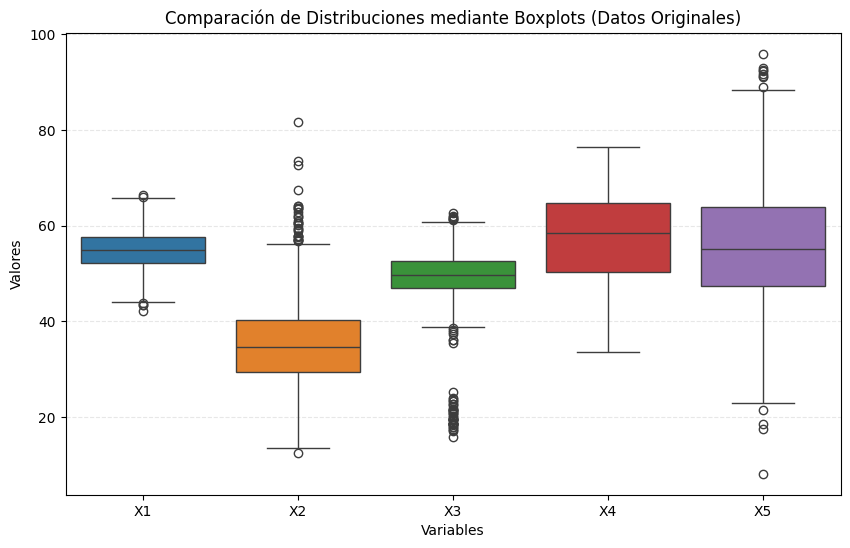

In [4]:
# Para representar las 5 variables cuantitativas en un único gráfico, 
# una de las mejores opciones es utilizar un Boxplot.
plt.figure(figsize=(10, 6))
sns.boxplot(data=data)

plt.title("Comparación de Distribuciones mediante Boxplots (Datos Originales)")
plt.xlabel("Variables")
plt.ylabel("Valores")
plt.grid(True, axis='y', alpha=0.3, linestyle='--')
plt.show()

- $X1$ (Azul): Es la distribución más compacta y estable. Presenta una dispersión muy baja (la caja es angosta) y es altamente simétrica, ya que la mediana está justo en el centro de la caja y los bigotes miden casi lo mismo. Tiene unos pocos valores atípicos (outliers) simétricos tanto en la parte superior como en la inferior.

- $X2$ (Naranja): Su nivel general de valores es más bajo que el resto (mediana cercana a 35). Muestra una asimetría positiva (sesgada a la derecha): la caja se estira hacia arriba de la mediana, el bigote superior es notablemente más largo y presenta una gran cantidad de outliers concentrados únicamente en la parte superior, llegando hasta valores de 80.

- $X3$ (Verde): Tiene una dispersión intermedia y su caja es bastante simétrica en el centro, pero muestra una anomalía severa en su cola inferior: una asimetría negativa extrema en los valores atípicos. Cuenta con una gran concentración de outliers pesados en la parte inferior (valores entre 15 y 25), lo que sugiere una cola izquierda muy larga en su distribución.

- $X4$ (Rojo): Es una distribución muy limpia y simétrica, con una dispersión intermedia-alta (caja más alta). Lo más destacable estadísticamente es que no presenta absolutamente ningún valor atípico (outlier), ni arriba ni abajo.

- $X5$ (Morado): Es la variable con mayor dispersión de todas (el rango intercuartílico, es decir, la altura de la caja, es el más amplio). Es mayormente simétrica en su cuerpo, pero presenta outliers en ambos extremos (algunos muy bajos cerca de 10 y otros muy altos rozando el 100).

## Item 2

En función a la respuesta al ítem anterior, ¿qué medidas de posición y dispersión le parecen más adecuadas para describir a cada uno de estos conjuntos de datos?

1) Para las variables simétricas y sin anomalías extremas ($X1$ y $X4$) 

    - Medida de posición: Media aritmética $\bar{x}$. Al ser distribuciones simétricas, la media se ubica en el centro geométrico y representa fielmente al conjunto.

    - Medida de dispersión: Desviación estándar $s$. Al no haber outliers severos que la distorsionen, es el parámetro ideal para medir la variabilidad.

2) Para las variables asimétricas o con outliers severos ($X2$, $X3$ y $X5$)

    - Medida de posición: Mediana $\tilde{x}$. Es una medida robusta. En $X2$ y $X3$, los outliers arrastrarían falsamente a la media hacia arriba o hacia abajo; la mediana permanece inmóvil reflejando el verdadero centro del 50% de los datos.
    
    - Medida de dispersión: Rango Intercuartílico IQR. Al calcular la distancia entre el tercer y el primer cuartil ($Q_3 - Q_1$), mide la dispersión del corazón de los datos ignorando por completo las colas de valores atípicos que distorsionarían a la desviación estándar.

## Item 3

Realice el escalado de este grupo de variables a través de cada una de las técnicas presentadas en clases (Z-Score, escalado min-max, escalado máximo absoluto y escalado robusto). En cada caso, represente gráficamente las variables transformadas y comente brevemente lo observado.

In [5]:
# Cargamos lo necesario

# apply the maximum absolute scaling in Pandas using the .abs() and .max() methods
def maximum_absolute_scaling(df):
    # copy the dataframe
    df_scaled = df.copy()
    # apply maximum absolute scaling
    for column in df_scaled.columns:
        df_scaled[column] = df_scaled[column]  / df_scaled[column].abs().max()
    return df_scaled

# apply the min-max scaling in Pandas using the .min() and .max() methods
def min_max_scaling(df):
    # copy the dataframe
    df_norm = df.copy()
    # apply min-max scaling
    for column in df_norm.columns:
        df_norm[column] = (df_norm[column] - df_norm[column].min()) / (df_norm[column].max() - df_norm[column].min())
        
    return df_norm

# apply the z-score method in Pandas using the .mean() and .std() methods
def z_score(df):
    # copy the dataframe
    df_std = df.copy()
    # apply the z-score method
    for column in df_std.columns:
        df_std[column] = (df_std[column] - df_std[column].mean()) / df_std[column].std()
        
    return df_std

# apply the robust scaling in Pandas using the .median() and .quantile() methods
def robust_scaling(df):
    # copy the dataframe
    df_robust = df.copy()
    # apply robust scaling
    for column in df_robust.columns:
        df_robust[column] = (df_robust[column] - df_robust[column].median())  / (df_robust[column].quantile(0.75) - df_robust[column].quantile(0.25))
    return df_robust

In [6]:
# Aplicamos los escalados
escala_maxima_abs = maximum_absolute_scaling(data)
min_max = min_max_scaling(data)
puntaje_z = z_score(data)
escalado_robusto = robust_scaling(data)

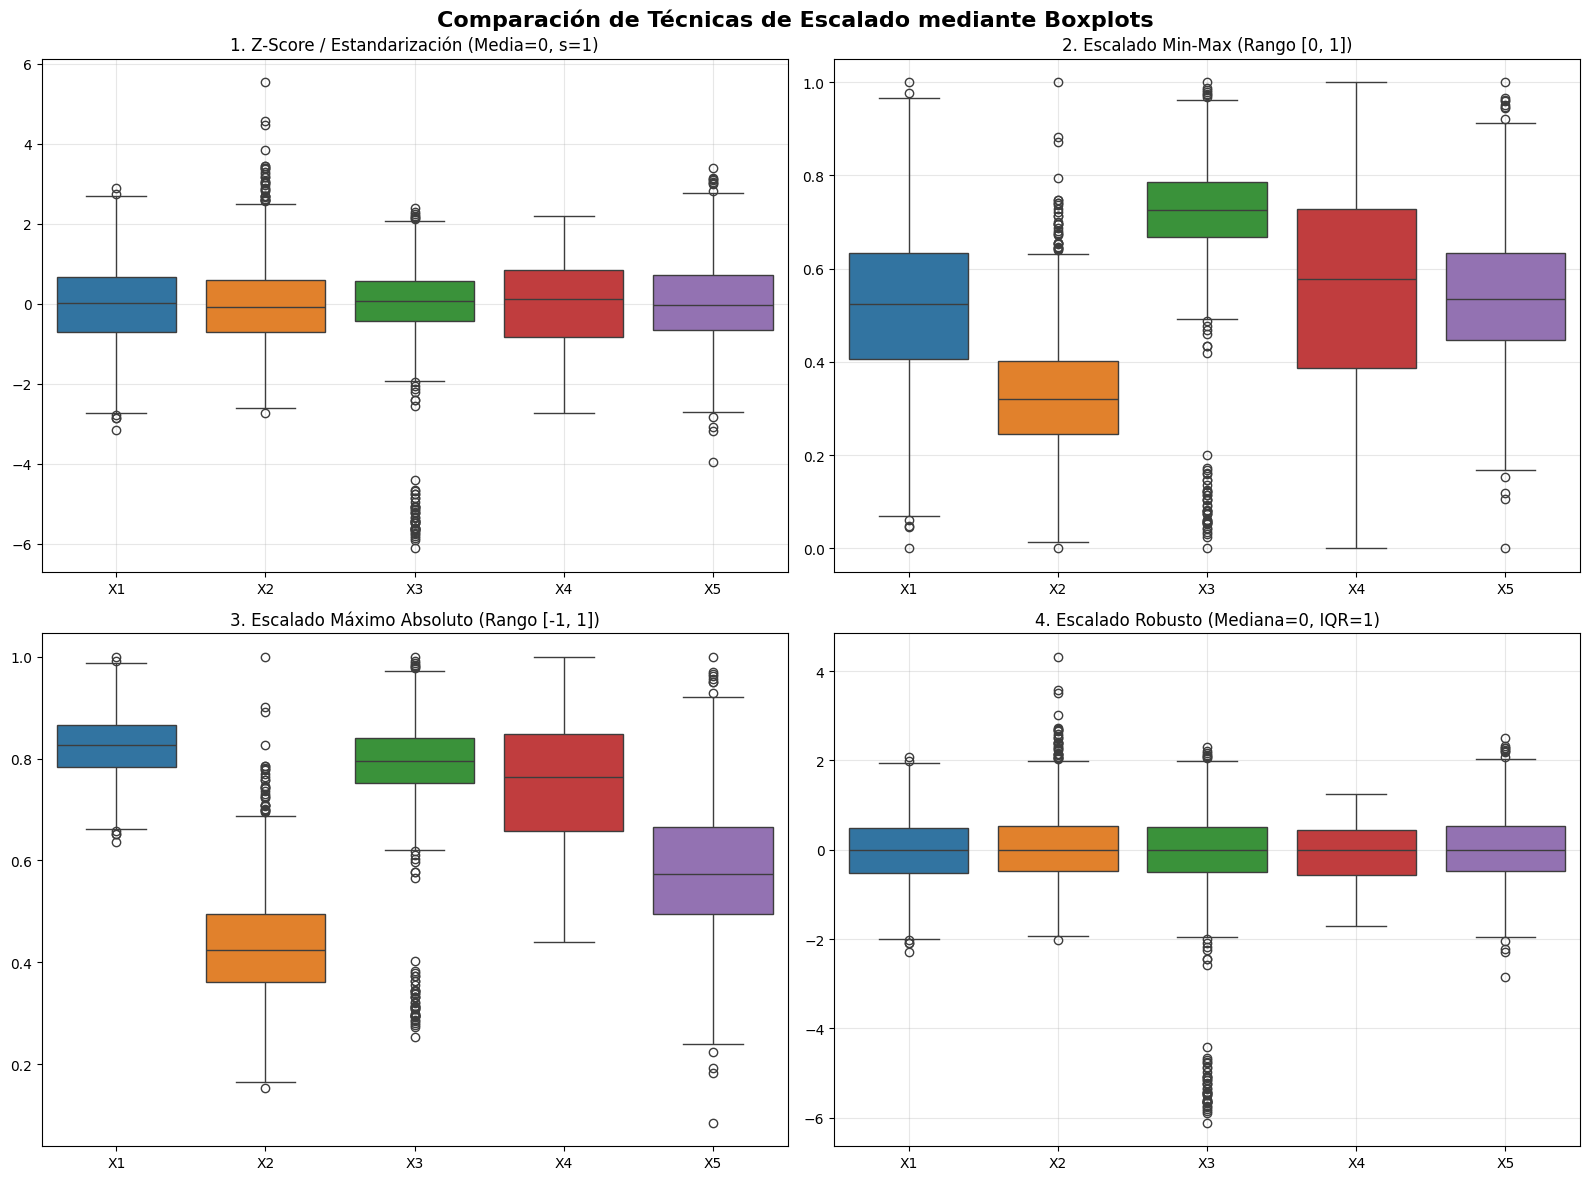

In [7]:
# Graficamos cada uno en su respectivo cuadrante
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.boxplot(data=puntaje_z, ax=axes[0, 0])
axes[0, 0].set_title("1. Z-Score / Estandarización (Media=0, s=1)")
axes[0, 0].grid(True, alpha=0.3)

sns.boxplot(data=min_max, ax=axes[0, 1])
axes[0, 1].set_title("2. Escalado Min-Max (Rango [0, 1])")
axes[0, 1].grid(True, alpha=0.3)

sns.boxplot(data=escala_maxima_abs, ax=axes[1, 0])
axes[1, 0].set_title("3. Escalado Máximo Absoluto (Rango [-1, 1])")
axes[1, 1].grid(True, alpha=0.3)

sns.boxplot(data=escalado_robusto, ax=axes[1, 1])
axes[1, 1].set_title("4. Escalado Robusto (Mediana=0, IQR=1)")
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle("Comparación de Técnicas de Escalado mediante Boxplots", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()